## Convocatoria 1 - Proyecto 1

#### 0) Cargar una de las imágenes histológicas

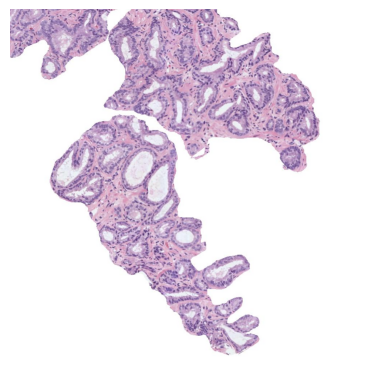

In [137]:
# Visualizar la imagen
import skimage.io as io
import numpy as np 
import matplotlib.pyplot as plt
import cv2

# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
img = io.imread(r'histo_2.jpg')  # Asegúrate de que la ruta sea correcta

# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
#esta línea convierte los valores de píxeles a float32 y los divide por 255 para normalizar a [0, 1]
rgb_p = img.astype('uint8')/255
#rgb_p = img.astype(np.float32) / 255.0 
'''normaliza los valores de los píxeles de la imagen porque originalmente están en el rango [0, 255] (tipo uint8).
Al dividir cada valor por 255.0, todos los valores pasan al rango [0, 1], que es el estándar para trabajar 
con imágenes normalizadas en muchos algoritmos y librerías de procesamiento de imágenes.'''

# Visualizar la imagen normalizada
plt.imshow(rgb_p)
plt.axis('off')
plt.show()


#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

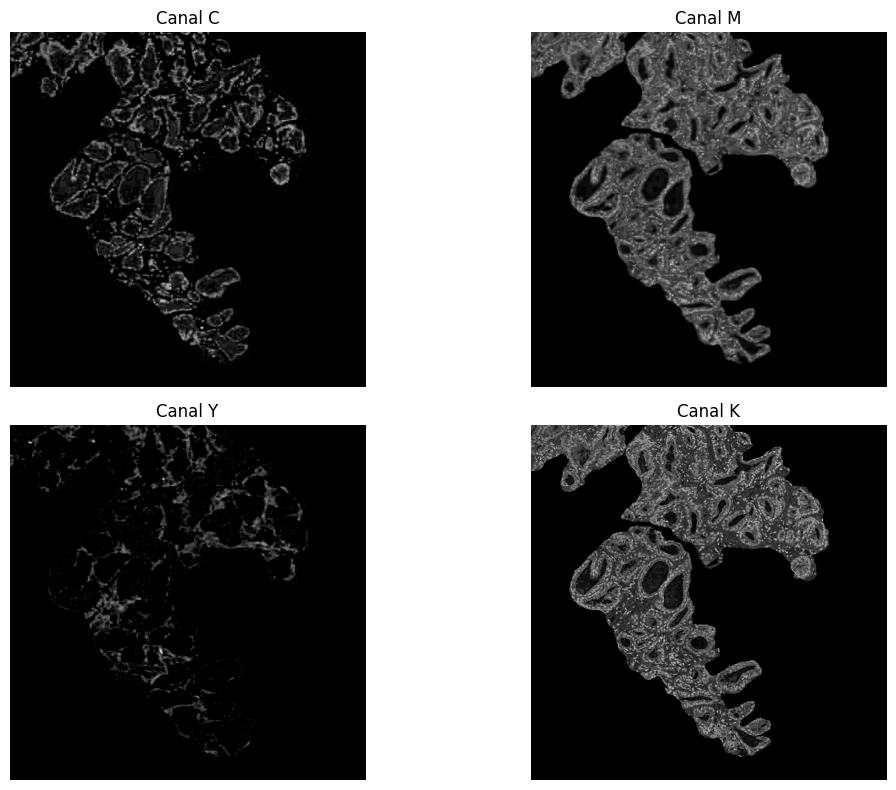

In [138]:
#convertir la imagen RGB a CMYK
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)
    # Extrae los canales de acuerdo con la ecuación del power point
    C = np.where(K < 1, (1 - rgb_p[:,:,0] - K) / (1 - K), 0)
    M = np.where(K < 1, (1 - rgb_p[:,:,1] - K) / (1 - K), 0)
    Y = np.where(K < 1, (1 - rgb_p[:,:,2] - K) / (1 - K), 0)

C = np.nan_to_num(C)
M = np.nan_to_num(M)
Y = np.nan_to_num(Y)
K = np.nan_to_num(K)
CMYK = (np.dstack((C,M,Y,K))*255).astype('uint8')
C,M,Y,K = cv2.split(CMYK)

# Extraer canales los componente de la imagen (que corresponde a la región tisular)
# Visualizar la imagen de lo los canales C, M, Y y K
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(C, cmap='gray')
plt.title('Canal C')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(M, cmap='gray')
plt.title('Canal M')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Y, cmap='gray')
plt.title('Canal Y')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(K, cmap='gray')
plt.title('Canal K')
plt.axis('off')
plt.tight_layout()
plt.show()





#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

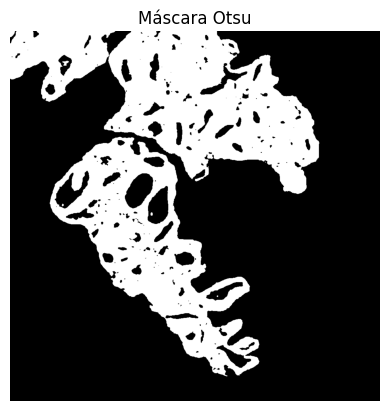

In [139]:
# A la imagen CMYK Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante
# Aplicar un filtro gaussiano de tamaño 5x5

blurred = cv2.GaussianBlur(CMYK, (5, 5), 0)
# Convertir la imagen a escala de grises
gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
# Aplicar el método de Otsu para obtener la máscara
_, gauss_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# Visualizar la máscara resultante
plt.imshow(gauss_mask, cmap='gray')
plt.axis('off')
plt.title('Máscara Otsu')
plt.show()


#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

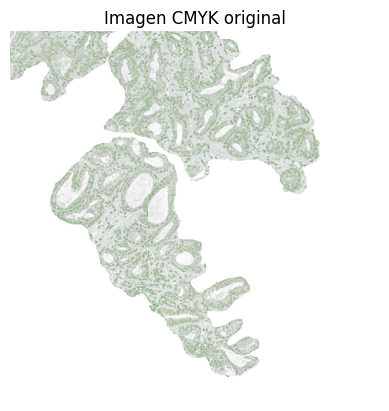

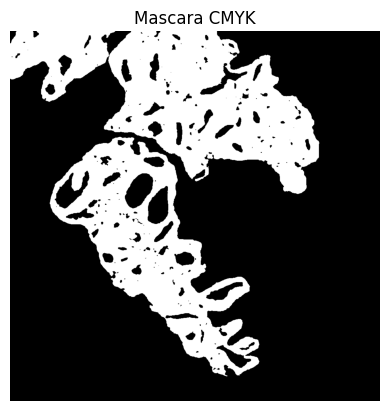

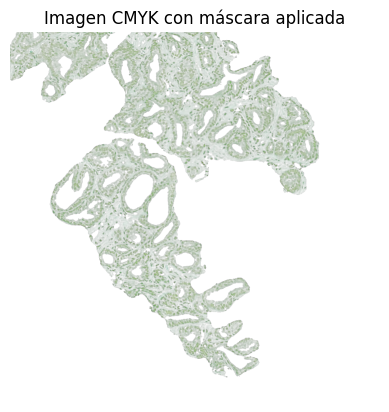

In [140]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos de la imagen CMYK cuya área sea menor a 300 píxeles usando la mascara gauss_mask
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

# Visualizar la imagen CMYK original
plt.imshow(CMYK)
plt.axis('off')
plt.title('Imagen CMYK original')
plt.show()

# Aplicar remove_small_objects a la imagen CMYK
from skimage.morphology import remove_small_objects

gauss_mask_bool = gauss_mask > 0  # Convertir mascara gausseana a booleano
# Eliminar objetos pequeños de la imagen CMYK
cmyk_mask = remove_small_objects(gauss_mask_bool, min_size=300, connectivity=2)
# Convertir la imagen limpia a uint8 para visualizarla
cmyk_mask_uint8 = (cmyk_mask * 255).astype(np.uint8)
# Visualizar la mascara
plt.imshow(cmyk_mask_uint8, cmap='gray')
plt.axis('off')
plt.title('Mascara CMYK')
plt.show()

# aplicar la máscara obtenida a la imagen CMYK original
# Visualizar la imagen CMYK original con la máscara aplicada
masked_cmyk = CMYK.copy()
masked_cmyk[~cmyk_mask] = 0  # Aplicar la máscara
plt.imshow(masked_cmyk)
plt.axis('off')
plt.title('Imagen CMYK con máscara aplicada')
plt.show()


#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [141]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) a la imagen masked_cmyk de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.

def region_growing(image, seeds, threshold=0.1):
    segmented = np.zeros(image.shape[:2], dtype=np.uint8)
    for seed in seeds:
        x, y = seed
        if segmented[x, y] == 0:  # Si el píxel no ha sido segmentado
            region = [(x, y)]
            while region:
                x, y = region.pop()
                if segmented[x, y] == 0:  # Si el píxel no ha sido segmentado
                    segmented[x, y] = 255  # Marcar como parte de la región
                    # Expandir a los vecinos
                    for dx in [-1, 0, 1]:
                        for dy in [-1, 0, 1]:
                            if dx != 0 or dy != 0:  # Evitar el píxel actual
                                nx, ny = x + dx, y + dy
                                if (0 <= nx < image.shape[0] and 
                                    0 <= ny < image.shape[1] and 
                                    segmented[nx, ny] == 0 and 
                                    np.abs(image[nx, ny] - image[x, y]) < threshold):
                                    region.append((nx, ny))
    return segmented


In [142]:
def find_seeds(image, num_seeds):
    # Si la imagen tiene 3 canales, conviértela a escala de grises
    if len(image.shape) == 3 and image.shape[2] == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image
    _, thresh = cv2.threshold(gray_image, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    seeds = []
    for contour in contours[:num_seeds]:
        M = cv2.moments(contour)
        if M['m00'] != 0:
            cX = int(M['m10'] / M['m00'])
            cY = int(M['m01'] / M['m00'])
            # Verifica si la semilla está sobre un lumen (valor 1)
            if gray_image[cY, cX] == 255:
                seeds.append((cY, cX))
            else:
                # Busca el punto del contorno que esté sobre un lumen
                for pt in contour:
                    px, py = pt[0]
                    if gray_image[py, px] == 255:
                        seeds.append((py, px))
                        break
    return seeds

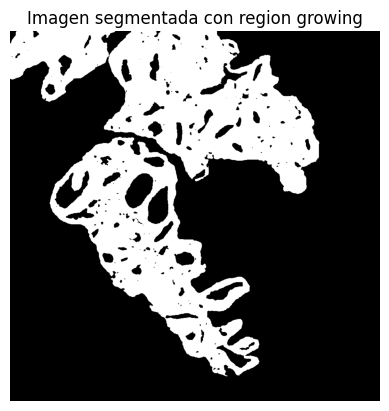

In [143]:
# Usar la máscara binaria limpia para encontrar semillas
seeds = find_seeds(cmyk_mask_uint8,10)

binary_mask = (cmyk_mask_uint8 > 0).astype(np.int32)

if len(seeds) == 0:
    print("No se encontraron semillas. Verifica la máscara binaria.")
    plt.imshow(cmyk_mask_uint8, cmap='gray')
    plt.axis('off')
    plt.title('Máscara binaria utilizada para semillas')
    plt.show()
else:
    # Usar la máscara binaria y threshold=1
    segmented_image = region_growing(binary_mask, seeds)
    plt.imshow(segmented_image, cmap='gray')
    plt.axis('off')
    plt.title('Imagen segmentada con region growing')
    plt.show()

#### 5) Rellenar los objetos de los lúmenes

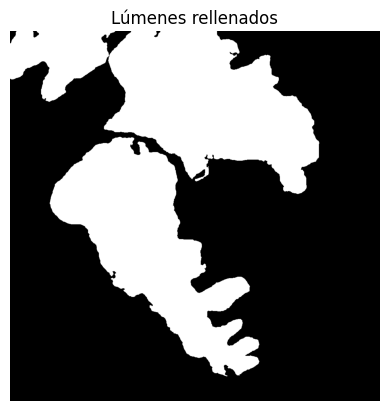

In [144]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
from scipy.ndimage import binary_fill_holes

# Rellenar los lúmenes en la imagen segmentada
filled_lumens = binary_fill_holes(segmented_image > 0)

# Visualizar la máscara resultante
plt.imshow(filled_lumens, cmap='gray')
plt.axis('off')
plt.title('Lúmenes rellenados')
plt.show()


#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

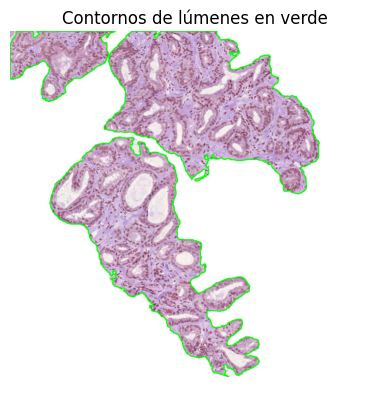

In [145]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios para que los contornos en verde sean perfectamente visibles. 

# Detectar contornos en la máscara de lúmenes rellenados
contours, _ = cv2.findContours(filled_lumens.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Crear una copia de la imagen original en formato uint8
img_rgb = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.copy()

# Dibujar los contornos en verde (BGR: (0,255,0)) sobre la imagen original
img_contours = img_rgb.copy()
cv2.drawContours(img_contours, contours, -1, (0,255,0), thickness=2)

# Visualizar el resultado
plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Contornos de lúmenes en verde')
plt.show()


#### 7) Identificar y cropear el lumen más grande

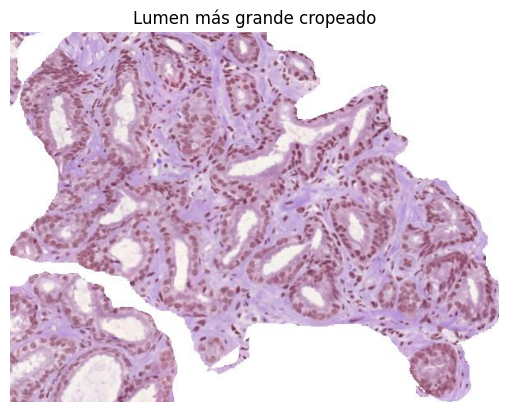

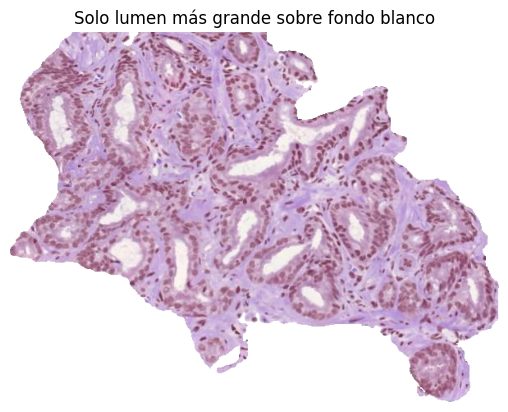

In [146]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.

# Encontrar el contorno de mayor área (lumen más grande)
largest_contour = max(contours, key=cv2.contourArea)

# Obtener el bounding box del lumen más grande
x, y, w, h = cv2.boundingRect(largest_contour)

# Cropear el lumen sobre la imagen original RGB
cropped_lumen = img_rgb[y:y+h, x:x+w]

# Visualizar el lumen cropeado
plt.imshow(cv2.cvtColor(cropped_lumen, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Lumen más grande cropeado')
plt.show()

# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB, 
# quedandose solo con ese lumen y el resto blanco

# Crear máscara del lumen más grande dentro del crop
mask_crop = np.zeros((h, w), dtype=np.uint8)
cv2.drawContours(mask_crop, [largest_contour - [x, y]], -1, 1, thickness=-1)

# Crear imagen blanca
crop_white_bg = np.ones_like(cropped_lumen) * 255

# Aplicar la máscara: donde mask_crop==1, mostrar el lumen, si no, blanco
for c in range(3):  # Para cada canal RGB
    crop_white_bg[:,:,c] = np.where(mask_crop == 1, cropped_lumen[:,:,c], 255)

# Visualizar el resultado
plt.imshow(cv2.cvtColor(crop_white_bg, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Solo lumen más grande sobre fondo blanco')
plt.show()


#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [147]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad



from skimage.measure import regionprops, label
from scipy.spatial import ConvexHull

# Crear máscara del lumen más grande dentro del crop
mask_crop = np.zeros((h, w), dtype=np.uint8)
cv2.drawContours(mask_crop, [largest_contour - [x, y]], -1, 1, thickness=-1)

# Calcular propiedades geométricas
props = regionprops(label(mask_crop))[0]
contour_points = largest_contour - [x, y]

# 1) Área
area = np.round(props.area, 4)
# 2) Área de la bounding box
bbox_area = np.round(props.bbox_area, 4)
# 3) Área convexa
hull = ConvexHull(contour_points.squeeze())
convex_area = np.round(hull.volume, 4)
# 4) Excentricidad
eccentricity = np.round(props.eccentricity, 4)
# 5) Diámetro equivalente
equiv_diameter = np.round(props.equivalent_diameter, 4)
# 6) Extensión
extent = np.round(props.extent, 4)
# 7) Diámetro Feret (máxima distancia entre dos puntos del contorno)
from scipy.spatial.distance import pdist
feret_diameter = np.round(np.max(pdist(contour_points.squeeze())), 4)
# 8) Longitud del eje mayor
major_axis_length = np.round(props.major_axis_length, 4)
# 9) Longitud del eje menor
minor_axis_length = np.round(props.minor_axis_length, 4)
# 10) Orientación
orientation = np.round(props.orientation, 4)
# 11) Perímetro
perimeter = np.round(props.perimeter, 4)
# 12) Solidez
solidity = np.round(props.solidity, 4)
# 13) Compacidad (perímetro^2 / (4*pi*área))
compacity = np.round((perimeter**2) / (4 * np.pi * area), 4)

# Mostrar resultados
features = {
    "Área": area,
    "Área bounding box": bbox_area,
    "Área convexa": convex_area,
    "Excentricidad": eccentricity,
    "Diámetro equivalente": equiv_diameter,
    "Extensión": extent,
    "Diámetro Feret": feret_diameter,
    "Longitud eje mayor": major_axis_length,
    "Longitud eje menor": minor_axis_length,
    "Orientación": orientation,
    "Perímetro": perimeter,
    "Solidez": solidity,
    "Compacidad": compacity
}

for k, v in features.items():
    print(f"{k}: {v}")

Área: 164091.0
Área bounding box: 268796.0
Área convexa: 201542.0
Excentricidad: 0.8379
Diámetro equivalente: 457.0855
Extensión: 0.6105
Diámetro Feret: 658.5135
Longitud eje mayor: 639.4189
Longitud eje menor: 349.0264
Orientación: 1.1229
Perímetro: 2474.9028
Solidez: 0.8109
Compacidad: 2.9704
